CREAR MODELO VAR

In [8]:
import pandas as pd
from statsmodels.tsa.api import VAR

CARGAR LA BASE

In [9]:
df = pd.read_csv("../data/processed/base_VAR_Ecuador.csv")

df["PIB_diff"] = df["PIB"].diff()

df = df.dropna()

df.head()

,Año,PIB,Inflacion,Desempleo,PIB_diff
1,2008,6.564921,8.400096,3.917,4.662492
2,2009,1.091013,5.159968,4.608,-5.473908
3,2010,4.029138,3.554377,4.088,2.938125
4,2011,8.481477,4.474533,3.458,4.452339
5,2012,5.783212,5.101722,3.235,-2.698264


CREAR LA BASE VAR

In [10]:
datos_var = df[["PIB_diff", "Inflacion", "Desempleo"]]

datos_var.head()

,PIB_diff,Inflacion,Desempleo
1,4.662492,8.400096,3.917
2,-5.473908,5.159968,4.608
3,2.938125,3.554377,4.088
4,4.452339,4.474533,3.458
5,-2.698264,5.101722,3.235


REZAGOS

In [11]:
from statsmodels.tsa.api import VAR

modelo = VAR(datos_var)

modelo_var = modelo.fit(1)   # o fit(2), según el rezago que hayas elegido

print(modelo_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 28, Jul, 2026
Time:                     20:47:32
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    2.98010
Nobs:                     16.0000    HQIC:                   2.43033
Log likelihood:          -75.3143    FPE:                    11.3945
AIC:                      2.40066    Det(Omega_mle):         5.83400
--------------------------------------------------------------------
Results for equation PIB_diff
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const              -26.710181         6.496615           -4.111           0.000
L1.PIB_diff         -0.328302         0.158317           -2.074           0.038
L1.Inflacion         0.112442         0.452737            0.2

In [12]:
seleccion = modelo.select_order(maxlags=2)
print(seleccion.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       4.237       4.379       69.26       4.236
1      2.366*      2.933*      11.09*      2.360*
2       2.907       3.899       23.15       2.897
-------------------------------------------------


VERIFICAR ESTABILIDAD

In [13]:
modelo_var.is_stable()

np.True_

In [14]:
if modelo_var.is_stable():
    print("El modelo VAR es estable.")
else:
    print("El modelo VAR NO es estable.")

El modelo VAR es estable.


In [15]:
modelo_var.roots

array([ 9.29370603-0.j, -7.05134748-0.j,  1.75136698-0.j])

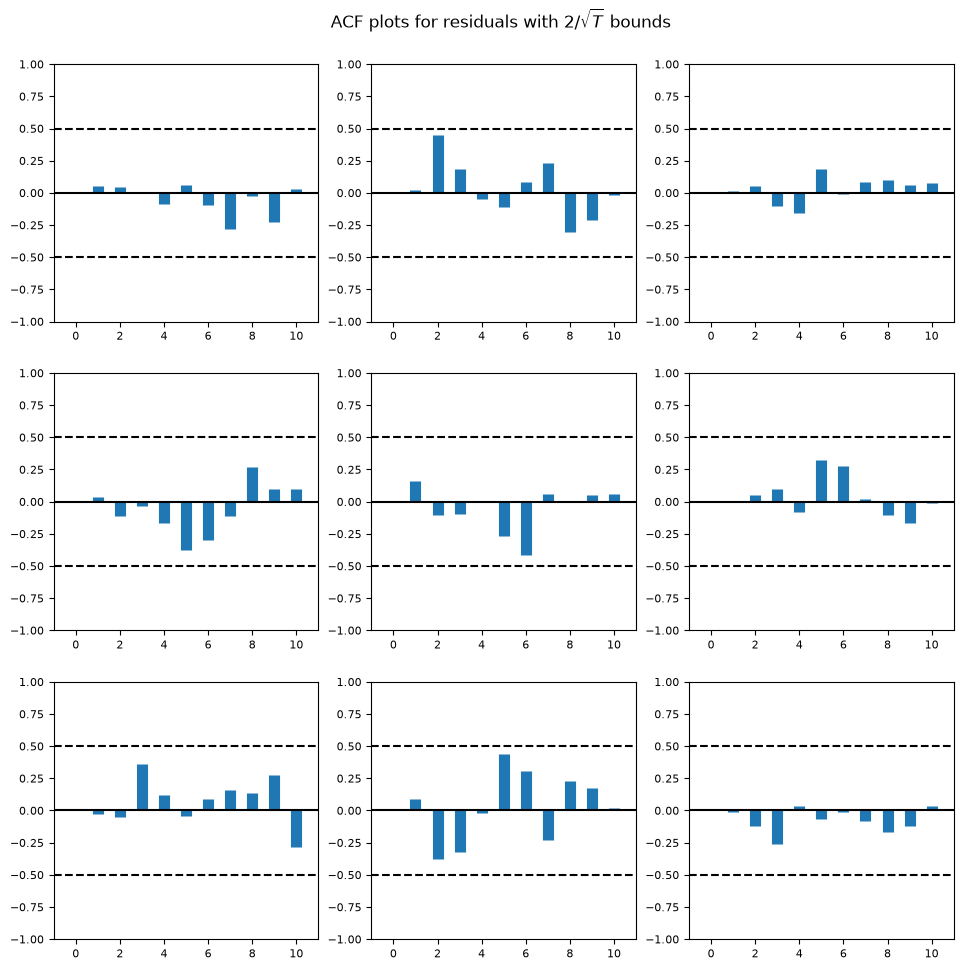

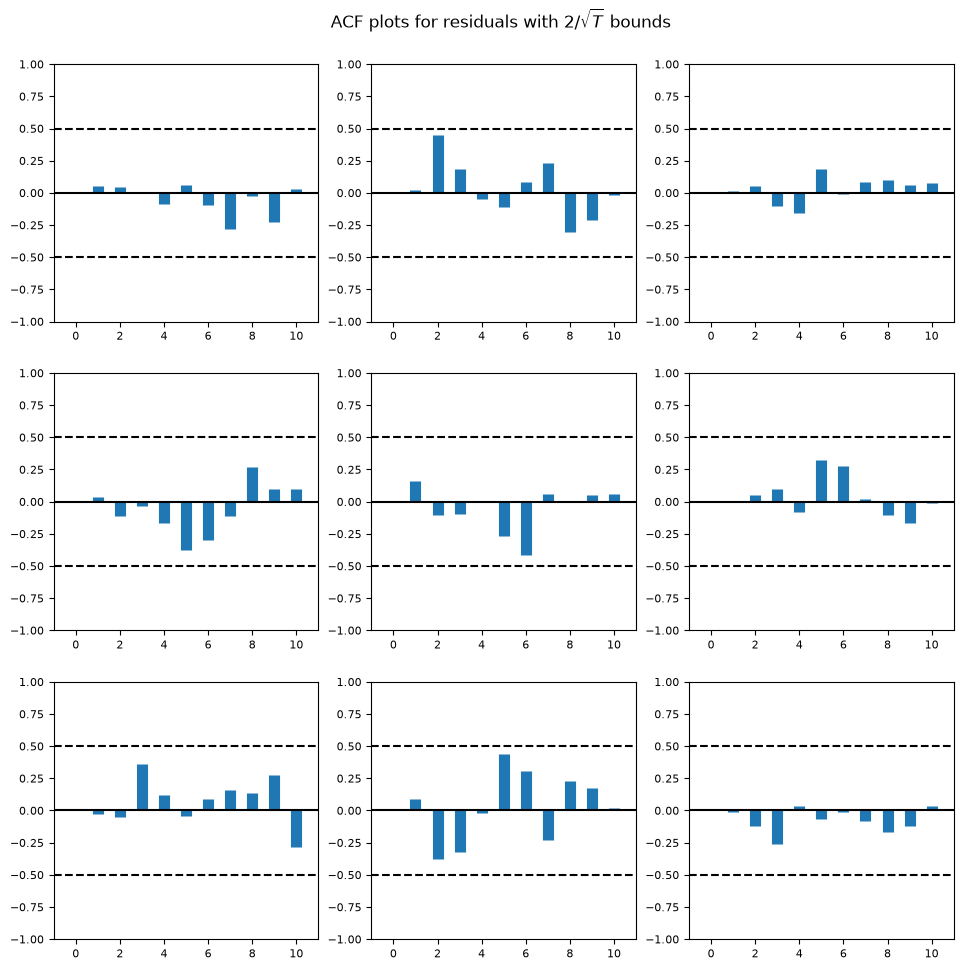

In [16]:
modelo_var.plot_acorr()

CUASALIDAD DE GRANGER

In [17]:
modelo_var.test_causality(
    caused="PIB_diff",
    causing=["Inflacion"],
    kind="f"
).summary()

Test statistic,Critical value,p-value,df
0.06168,4.113,0.805,"(1, 36)"


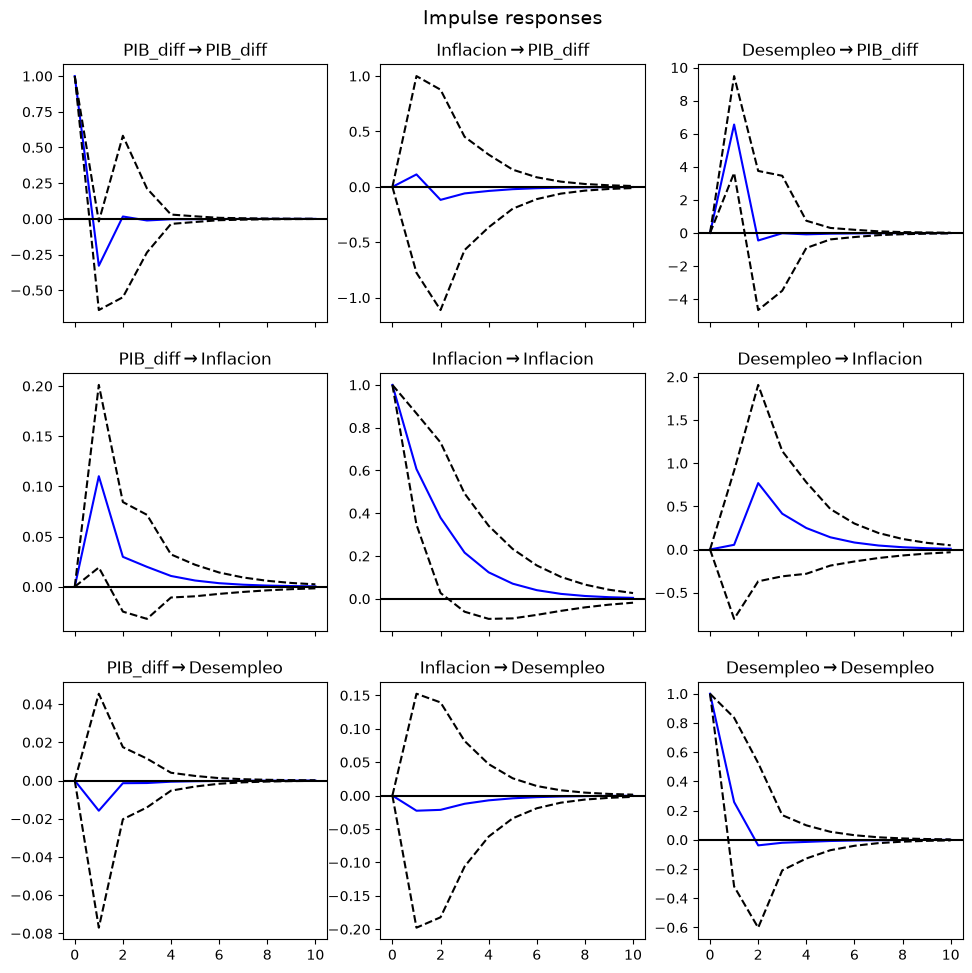

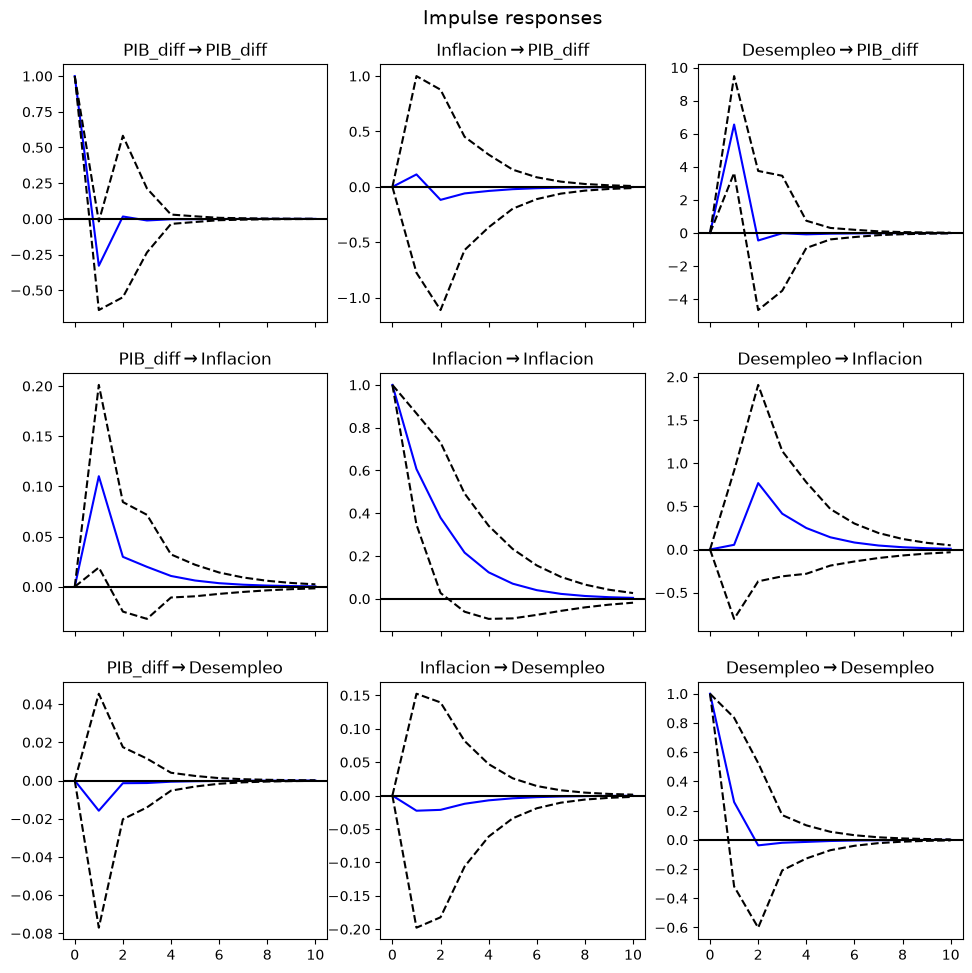

In [18]:
irf = modelo_var.irf(10)

irf.plot()

In [19]:
modelo_var = modelo.fit(1)

print(modelo_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 28, Jul, 2026
Time:                     20:47:38
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    2.98010
Nobs:                     16.0000    HQIC:                   2.43033
Log likelihood:          -75.3143    FPE:                    11.3945
AIC:                      2.40066    Det(Omega_mle):         5.83400
--------------------------------------------------------------------
Results for equation PIB_diff
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const              -26.710181         6.496615           -4.111           0.000
L1.PIB_diff         -0.328302         0.158317           -2.074           0.038
L1.Inflacion         0.112442         0.452737            0.2

VERIFICAR ESTABILIDAD Y LA ESTABILIDAD DE GRANGER

In [20]:
modelo_var.is_stable()

np.True_

ETABILIDAD DE GRANGER

LA INFLACION CAUSA AL PIB?

In [21]:
print(
    modelo_var.test_causality(
        caused="PIB_diff",
        causing="Inflacion",
        kind="f"
    ).summary()
)

Granger causality F-test. H_0: Inflacion does not Granger-cause PIB_diff. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
       0.06168          4.113   0.805 (1, 36)
---------------------------------------------


¿El desempleo causa al PIB?

In [22]:
print(
    modelo_var.test_causality(
        caused="PIB_diff",
        causing="Desempleo",
        kind="f"
    ).summary()
)

Granger causality F-test. H_0: Desempleo does not Granger-cause PIB_diff. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
         19.28          4.113   0.000 (1, 36)
---------------------------------------------


¿El PIB causa la inflación?

In [23]:
print(
    modelo_var.test_causality(
        caused="Inflacion",
        causing="PIB_diff",
        kind="f"
    ).summary()
)

Granger causality F-test. H_0: PIB_diff does not Granger-cause Inflacion. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
         5.630          4.113   0.023 (1, 36)
---------------------------------------------


¿El desempleo causa la inflación?

In [24]:
print(
    modelo_var.test_causality(
        caused="Inflacion",
        causing="Desempleo",
        kind="f"
    ).summary()
)

Granger causality F-test. H_0: Desempleo does not Granger-cause Inflacion. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
       0.01544          4.113   0.902 (1, 36)
---------------------------------------------


¿El PIB causa el desempleo?

In [25]:
print(
    modelo_var.test_causality(
        caused="Desempleo",
        causing="PIB_diff",
        kind="f"
    ).summary()
)

Granger causality F-test. H_0: PIB_diff does not Granger-cause Desempleo. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
        0.2555          4.113   0.616 (1, 36)
---------------------------------------------


¿La inflación causa el desempleo?

In [26]:
print(
    modelo_var.test_causality(
        caused="Desempleo",
        causing="Inflacion",
        kind="f"
    ).summary()
)

Granger causality F-test. H_0: Inflacion does not Granger-cause Desempleo. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df  
---------------------------------------------
       0.06421          4.113   0.801 (1, 36)
---------------------------------------------


Funciones Impulso–Respuesta (IRF)

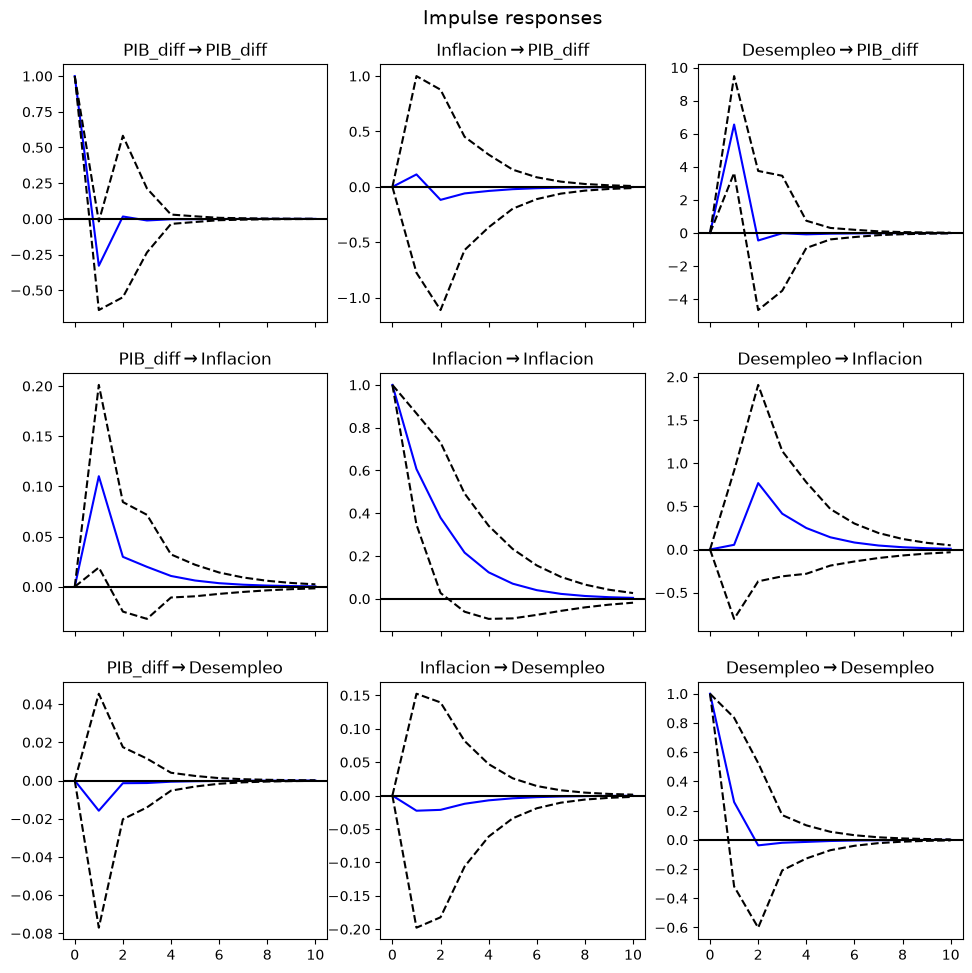

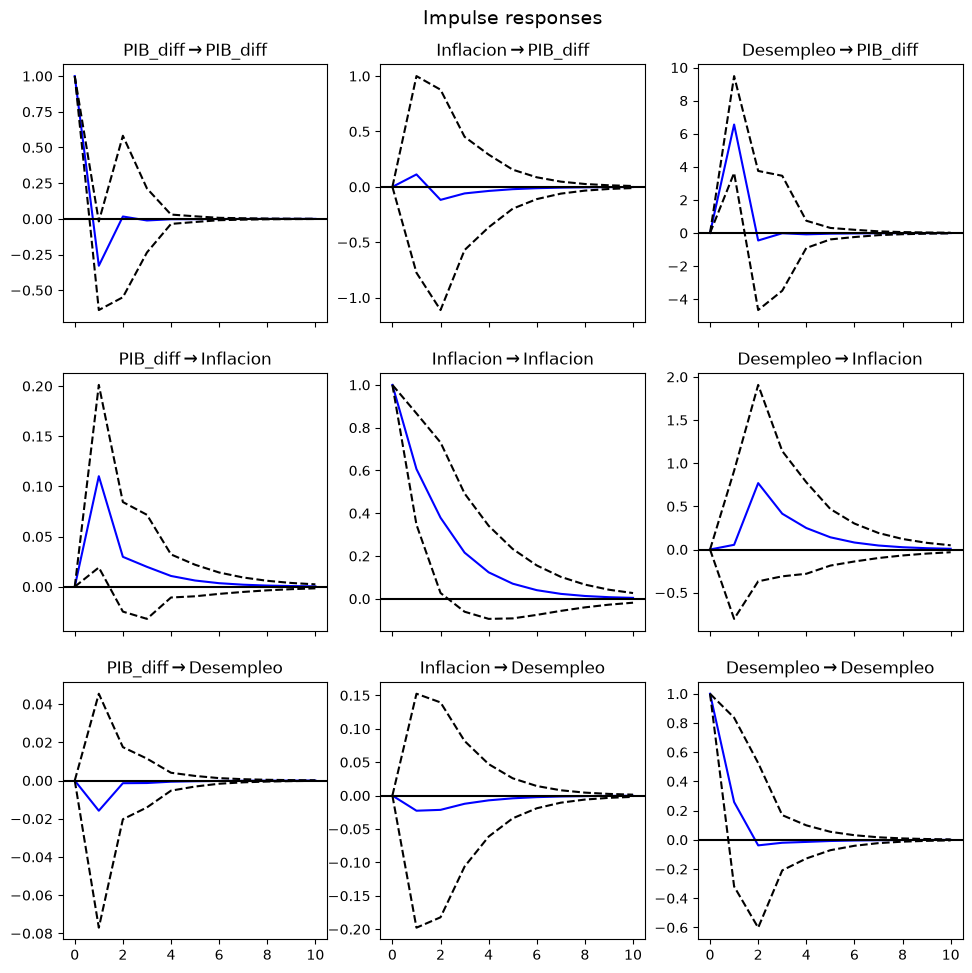

In [27]:
irf = modelo_var.irf(10)

irf.plot()

FEVD for PIB_diff
     PIB_diff  Inflacion  Desempleo
0    1.000000   0.000000   0.000000
1    0.746525   0.009521   0.243954
2    0.745931   0.009591   0.244478
3    0.745893   0.009664   0.244444
4    0.745854   0.009680   0.244466
5    0.745843   0.009686   0.244471
6    0.745840   0.009688   0.244473
7    0.745839   0.009688   0.244473
8    0.745838   0.009688   0.244473
9    0.745838   0.009688   0.244474

FEVD for Inflacion
     PIB_diff  Inflacion  Desempleo
0    0.123400   0.876600   0.000000
1    0.269662   0.729939   0.000399
2    0.246353   0.683013   0.070634
3    0.239371   0.672654   0.087975
4    0.237253   0.668783   0.093964
5    0.236569   0.667566   0.095864
6    0.236348   0.667168   0.096484
7    0.236276   0.667038   0.096686
8    0.236252   0.666996   0.096752
9    0.236245   0.666982   0.096773

FEVD for Desempleo
     PIB_diff  Inflacion  Desempleo
0    0.487976   0.026104   0.485920
1    0.505543   0.028300   0.466157
2    0.505003   0.028765   0.466231
3    0

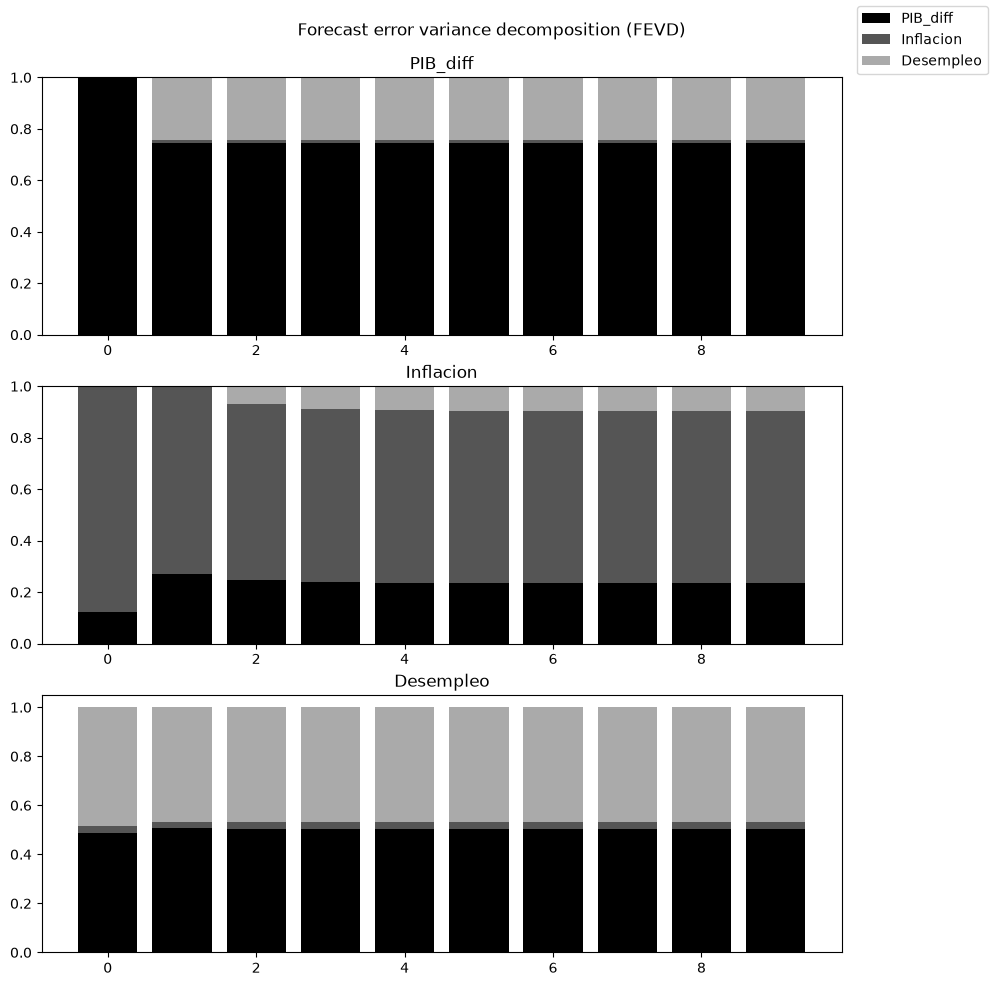

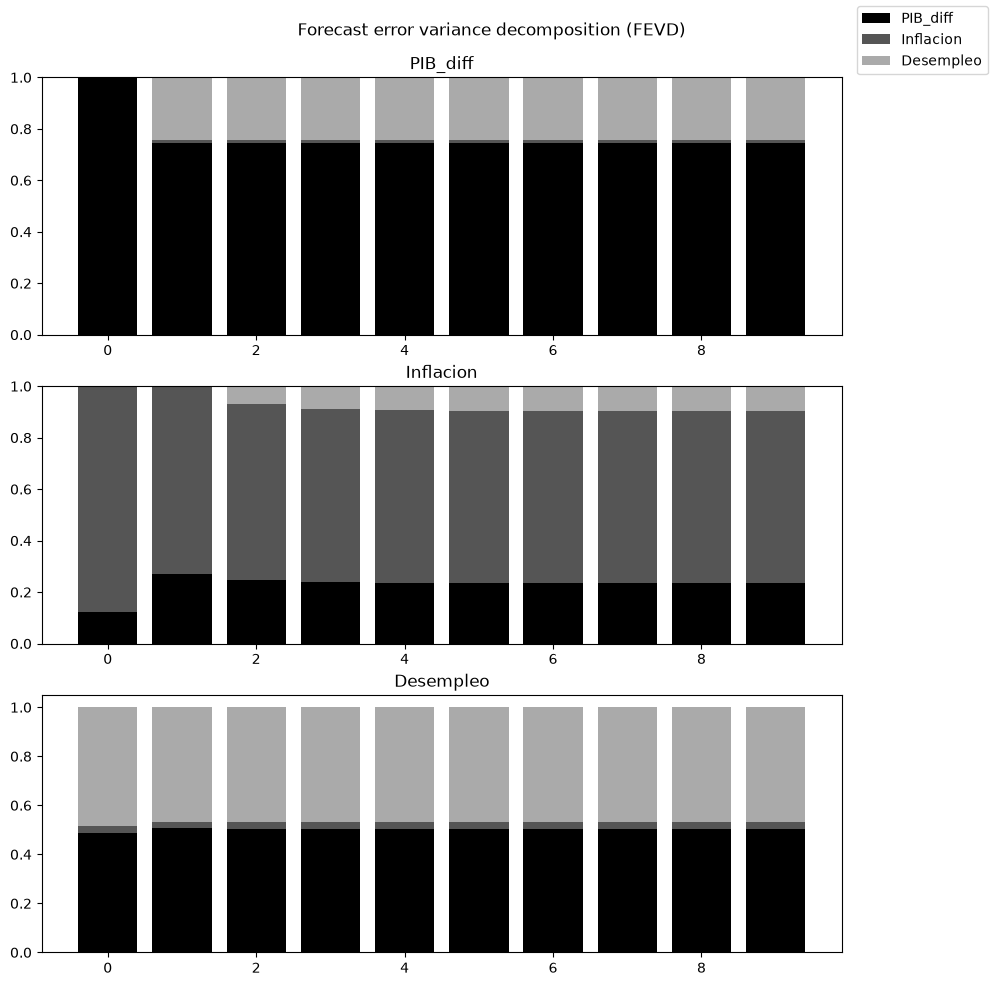

In [28]:
fevd = modelo_var.fevd(10)

print(fevd.summary())

fevd.plot()

Diagnóstico de autocorrelación de los residuos

In [29]:
df = pd.read_csv("../data/processed/base_VAR_Ecuador.csv")

df["PIB_diff"] = df["PIB"].diff()

df = df.dropna()

datos_var = df[["PIB_diff", "Inflacion", "Desempleo"]]

In [30]:
modelo = VAR(datos_var)

modelo_var = modelo.fit(1)

Durbin-Watson

In [31]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(modelo_var.resid)

for variable, valor in zip(datos_var.columns, dw):
    print(f"{variable}: {valor:.3f}")

PIB_diff: 1.807
Inflacion: 1.606
Desempleo: 1.893


Prueba de normalidad de los residuos

In [32]:
normalidad = modelo_var.test_normality()

print(normalidad.summary())

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         1.528          12.59   0.958  6
----------------------------------------


Análisis de robustez o especificación alternativa

In [33]:
modelo_var2 = modelo.fit(2)

print(modelo_var2.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 28, Jul, 2026
Time:                     20:47:42
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    3.89853
Nobs:                     15.0000    HQIC:                   2.89670
Log likelihood:          -64.6567    FPE:                    23.1515
AIC:                      2.90726    Det(Omega_mle):         7.33813
--------------------------------------------------------------------
Results for equation PIB_diff
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const              -27.946341        11.517784           -2.426           0.015
L1.PIB_diff         -0.189326         0.466951           -0.405           0.685
L1.Inflacion         0.201400         1.166750            0.1

In [34]:
print("AIC VAR(1):", modelo_var.aic)
print("AIC VAR(2):", modelo_var2.aic)

print("BIC VAR(1):", modelo_var.bic)
print("BIC VAR(2):", modelo_var2.bic)

AIC VAR(1): 2.4006562164902174
AIC VAR(2): 2.9072583674359027
BIC VAR(1): 2.9800977581700536
BIC VAR(2): 3.898528648978997
